In [1]:
import sys
import subprocess

packages = ['numpy', 'pandas', 'matplotlib', 'opencv-python', 'scikit-image', 'scikit-learn', 'joblib']

for pkg in packages:
    module_name = pkg.replace('-', '_')
    if pkg == 'opencv-python':
        module_name = 'cv2'
    elif pkg == 'scikit-image':
        module_name = 'skimage'
    elif pkg == 'scikit-learn':
        module_name = 'sklearn'
    try:
        __import__(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])


In [2]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from skimage.feature import hog
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42
IMG_SIZE = (64, 64)
DATA_DIR = Path('facial_sentiment_dataset')
MODEL_PATH = 'happy_sad_svm_hog_model.joblib'


In [3]:
def create_synthetic_face(label='happy', size=64):
    # Create a simple synthetic face image for demo purposes only.
    img = np.ones((size, size, 3), dtype=np.uint8) * 255
    cv2.circle(img, (size // 2, size // 2), 26, (200, 200, 200), 2)
    cv2.circle(img, (24, 26), 3, (0, 0, 0), -1)
    cv2.circle(img, (40, 26), 3, (0, 0, 0), -1)

    if label == 'happy':
        cv2.ellipse(img, (32, 38), (13, 9), 0, 0, 180, (0, 0, 0), 2)
    else:
        cv2.ellipse(img, (32, 48), (13, 9), 0, 180, 360, (0, 0, 0), 2)

    noise = np.random.normal(0, 8, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return img


def create_demo_dataset(root=DATA_DIR, n_per_class=120):
    np.random.seed(RANDOM_STATE)
    for label in ['happy', 'sad']:
        class_dir = root / label
        class_dir.mkdir(parents=True, exist_ok=True)
        existing = list(class_dir.glob('*'))
        if len(existing) >= n_per_class:
            continue
        for i in range(n_per_class):
            img = create_synthetic_face(label)
            cv2.imwrite(str(class_dir / f'{label}_{i:03d}.png'), img)


if not (DATA_DIR / 'happy').exists() or not (DATA_DIR / 'sad').exists():
    print('No real dataset found. Creating synthetic demo dataset...')
    create_demo_dataset()
else:
    print('Dataset folder found. Using existing images.')

print('Dataset path:', DATA_DIR.resolve())


No real dataset found. Creating synthetic demo dataset...
Dataset path: /content/facial_sentiment_dataset


In [4]:
def load_images_from_folders(root=DATA_DIR, img_size=IMG_SIZE):
    images, labels, paths = [], [], []
    label_map = {'happy': 1, 'sad': 0}

    for class_name, label in label_map.items():
        class_dir = root / class_name
        if not class_dir.exists():
            continue
        for img_path in class_dir.glob('*'):
            if img_path.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']:
                continue
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, img_size)
            images.append(gray)
            labels.append(label)
            paths.append(str(img_path))
    return np.array(images), np.array(labels), paths

images, labels, image_paths = load_images_from_folders()
print('Images loaded:', images.shape)
print('Labels loaded:', labels.shape)
print('Class counts:', pd.Series(labels).map({1: 'happy', 0: 'sad'}).value_counts().to_dict())


Images loaded: (240, 64, 64)
Labels loaded: (240,)
Class counts: {'happy': 120, 'sad': 120}


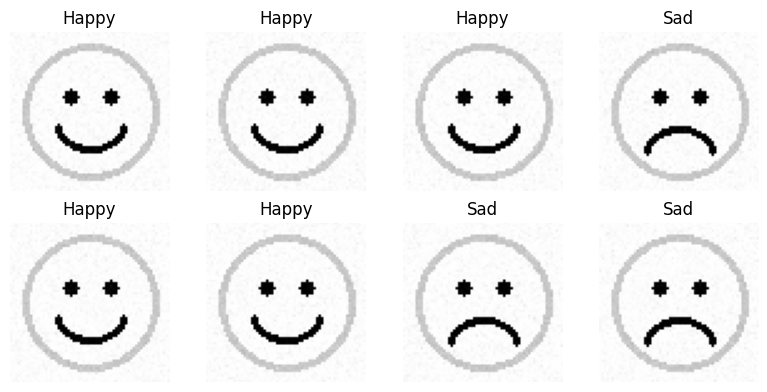

In [5]:
class_names = {0: 'Sad', 1: 'Happy'}

plt.figure(figsize=(8, 4))
for i, idx in enumerate(np.random.choice(len(images), size=min(8, len(images)), replace=False)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[idx], cmap='gray')
    plt.title(class_names[labels[idx]])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [6]:
def extract_hog_features(images):
    features, hog_images = [], []
    for img in images:
        fd, hog_img = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            visualize=True,
            feature_vector=True
        )
        features.append(fd)
        hog_images.append(hog_img)
    return np.array(features), np.array(hog_images)

X, hog_images = extract_hog_features(images)
y = labels
print('HOG feature matrix:', X.shape)
print('Target vector:', y.shape)


HOG feature matrix: (240, 1764)
Target vector: (240,)


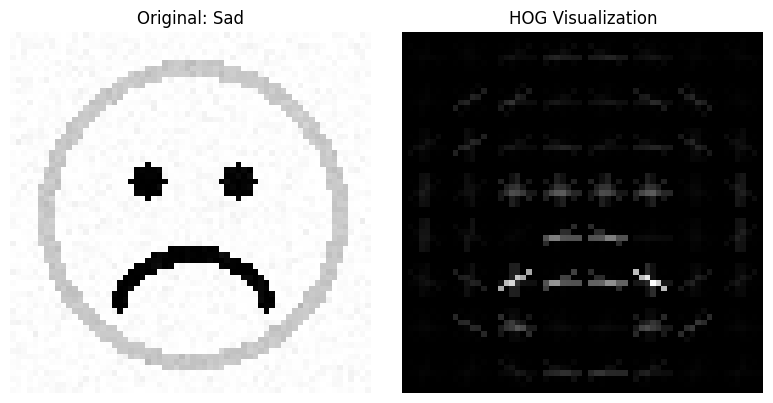

In [7]:
idx = np.random.randint(0, len(images))
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(images[idx], cmap='gray')
plt.title(f'Original: {class_names[y[idx]]}')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(hog_images[idx], cmap='gray')
plt.title('HOG Visualization')
plt.axis('off')
plt.tight_layout()
plt.show()


Train shape: (192, 1764)
Test shape: (48, 1764)


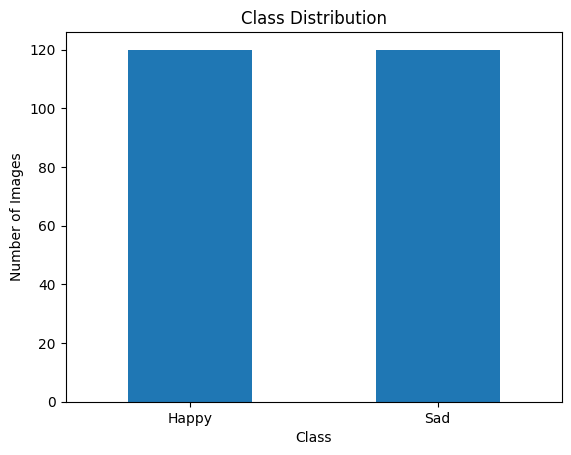

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

class_dist = pd.Series(y).map(class_names).value_counts()
class_dist.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)
plt.show()


In [9]:
models = {
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=RANDOM_STATE))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results, trained_models = [], {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'CV Accuracy Mean': cv_scores.mean(),
        'CV Accuracy Std': cv_scores.std(),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
results_df


,Model,CV Accuracy Mean,CV Accuracy Std,Test Accuracy,Precision,Recall,F1 Score
0,SVM,1.0,0.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,0.0,1.0,1.0,1.0,1.0
2,KNN,1.0,0.0,1.0,1.0,1.0,1.0


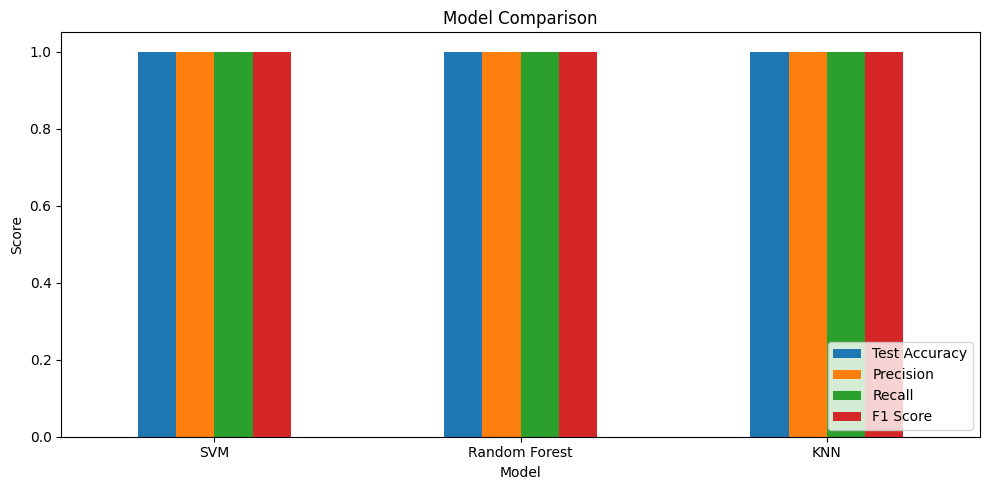

In [10]:
results_df.set_index('Model')[['Test Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar', figsize=(10, 5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [12]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print('Best model based on F1:', best_model_name)

svm_model = trained_models['SVM']
y_pred_svm = svm_model.predict(X_test)

print('SVM Classification Report:', classification_report(y_test, y_pred_svm, target_names=['Sad', 'Happy']))


Best model based on F1: SVM
SVM Classification Report:               precision    recall  f1-score   support

         Sad       1.00      1.00      1.00        24
       Happy       1.00      1.00      1.00        24

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



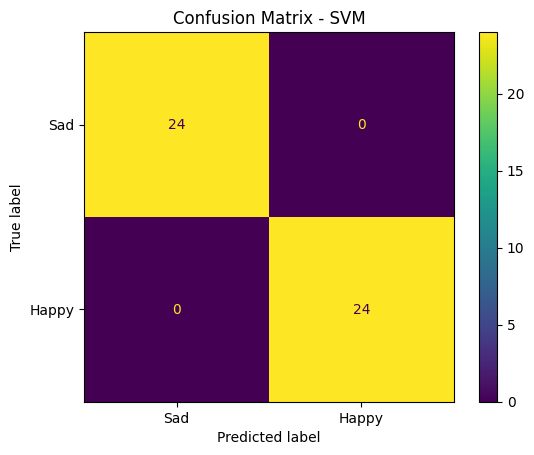

In [13]:
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sad', 'Happy'])
disp.plot(values_format='d')
plt.title('Confusion Matrix - SVM')
plt.show()


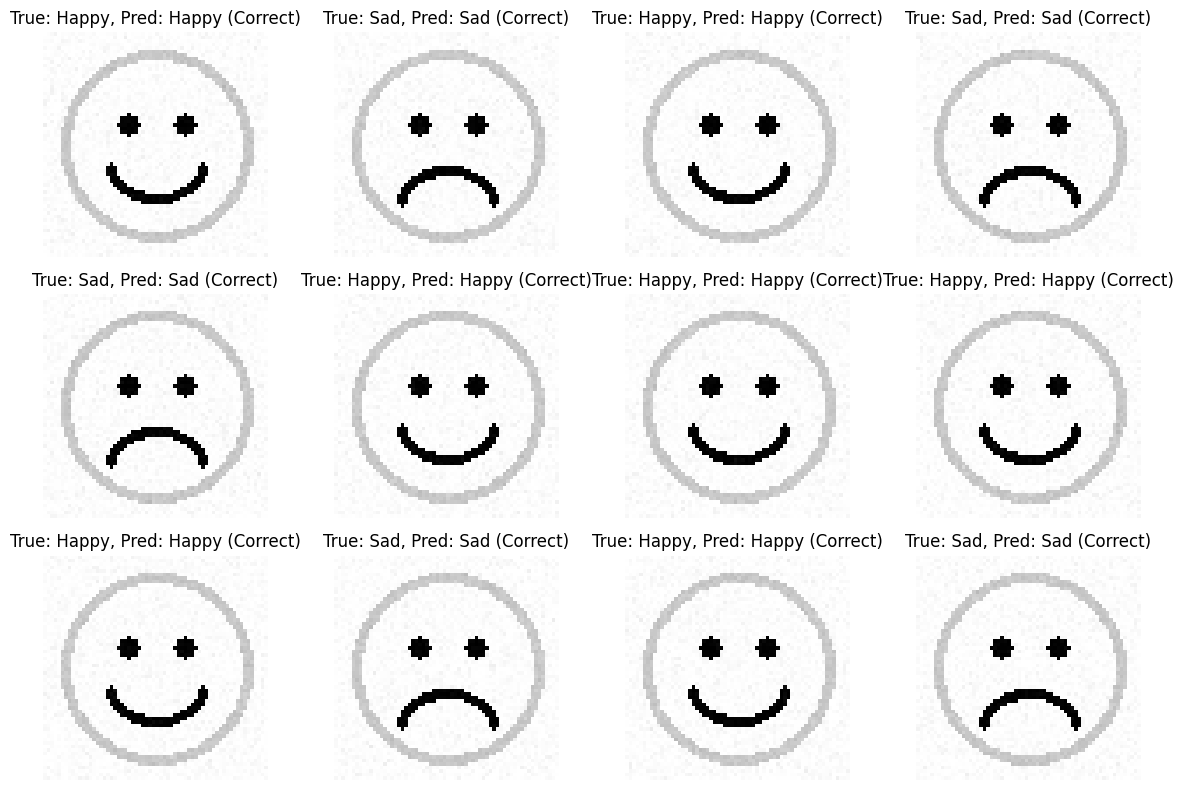

In [15]:
indices = np.arange(len(images))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

sample_count = min(12, len(test_idx))
sample_indices = np.random.choice(
    np.arange(len(test_idx)),
    size=sample_count,
    replace=False
)

plt.figure(figsize=(12, 8))

for i, local_idx in enumerate(sample_indices):
    original_idx = test_idx[local_idx]

    true_label = y_test[local_idx]
    pred_label = y_pred_svm[local_idx]

    status = "Correct" if true_label == pred_label else "Wrong"

    plt.subplot(3, 4, i + 1)
    plt.imshow(images[original_idx], cmap='gray')

    plt.title(
        f"True: {class_names[true_label]}, "
        f"Pred: {class_names[pred_label]} ({status})"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [16]:
joblib.dump({'model': svm_model, 'img_size': IMG_SIZE, 'class_names': class_names}, MODEL_PATH)
print('Saved model to:', MODEL_PATH)


Saved model to: happy_sad_svm_hog_model.joblib


{'prediction': 'Sad', 'confidence': 0.991}


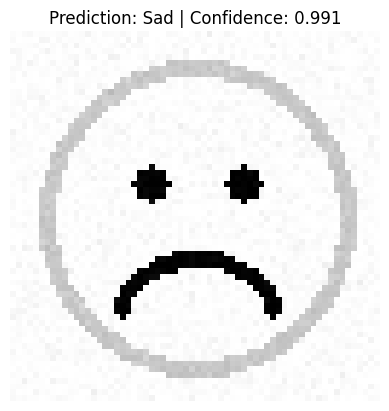

In [17]:
def preprocess_and_extract_hog(image_path, img_size=IMG_SIZE):
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f'Could not read image: {image_path}')
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, img_size)
    fd = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )
    return gray, fd.reshape(1, -1)


def predict_facial_sentiment(image_path, model_path=MODEL_PATH):
    saved = joblib.load(model_path)
    model = saved['model']
    class_names = saved['class_names']
    gray, features = preprocess_and_extract_hog(image_path, saved['img_size'])
    pred = model.predict(features)[0]
    prob = model.predict_proba(features)[0][pred] if hasattr(model, 'predict_proba') else None
    return {'prediction': class_names[pred], 'confidence': None if prob is None else round(float(prob), 4)}, gray

example_path = image_paths[test_idx[0]]
result, gray_img = predict_facial_sentiment(example_path)
print(result)
plt.imshow(gray_img, cmap='gray')
plt.title(f"Prediction: {result['prediction']} | Confidence: {result['confidence']}")
plt.axis('off')
plt.show()
